In [1]:
print("Hello")  

Hello


In [2]:
from schemas import QuestionPaperBlueprint, Section, QuestionSpec, QuestionType, SubPart, Slot, SlotSubPart, GenerationMode

In [3]:
question_paper = QuestionPaperBlueprint(
    school_name='SADHU VASWANI INTERNATIONAL SCHOOL',
    exam_title='PRE-MID TERM EXAMINATION: 2026-2027',
    subject='MATHEMATICS',
    grade=10,
    total_marks=40,
    duration_minutes=120,
    general_instructions=[
        'This question paper contains 19 questions. All questions are compulsory.',
        'This question paper is divided into five Sections -- A, B, C, D and E.',
        'In Section A, Question no. 1 to 8 are multiple choice questions (MCQs) and Question no. 9 and 10 are Assertion-Reason based questions of 1 mark each.',
        'In Section B, Question no. 11 and 12 are very short answer (VSA) type questions, carrying 2 marks each.',
        'In Section C, Question no. 13 to 15 are short answer (SA) type questions, carrying 3 marks each.',
        'In Section D, Question no. 16 and 17 are long answer (LA) type questions, carrying 5 marks each.',
        'Section E, Question no. 18 and 19 are Case Study based questions carrying 4 marks and 3 marks each.',
        'There is no overall choice. However an internal choice is provided in 1 Question in Section B, 1 Question in Section C, 1 Question in Section D and 1 Question in Section E.',
        'Draw neat diagrams wherever required.',
        'Use of calculator is not allowed.',
    ],
    sections=[
        Section(
            section_name='Section A',
            section_instructions='This section comprises Multiple Choice Questions (MCQs) of 1 mark each. 10X1=10M',
            questions=[
                QuestionSpec(question_number=i, question_type=QuestionType.MCQ, marks=1.0, has_internal_choice=False, sub_parts=[])
                for i in range(1, 9)
            ] + [
                QuestionSpec(question_number=9, question_type=QuestionType.ASSERTION_REASON, marks=1.0, has_internal_choice=False, sub_parts=[]),
                QuestionSpec(question_number=10, question_type=QuestionType.ASSERTION_REASON, marks=1.0, has_internal_choice=False, sub_parts=[]),
            ],
            stated_total_marks=10.0,
        ),
        Section(
            section_name='Section B',
            section_instructions='This section comprises Very Short Answer (VSA) type questions of 2 marks each. 2X2=4M',
            questions=[
                QuestionSpec(
                    question_number=11, question_type=QuestionType.VSA, marks=2.0, has_internal_choice=True,
                    sub_parts=[SubPart(label='a', marks=2.0, has_internal_choice=False), SubPart(label='b', marks=2.0, has_internal_choice=False)],
                ),
                QuestionSpec(question_number=12, question_type=QuestionType.VSA, marks=2.0, has_internal_choice=False, sub_parts=[]),
            ],
            stated_total_marks=4.0,
        ),
        Section(
            section_name='Section C',
            section_instructions='This section comprises Short Answer (SA) type questions of 3 marks each. 3X3 = 9M',
            questions=[
                QuestionSpec(question_number=13, question_type=QuestionType.SA, marks=3.0, has_internal_choice=False, sub_parts=[]),
                QuestionSpec(
                    question_number=14, question_type=QuestionType.SA, marks=3.0, has_internal_choice=True,
                    sub_parts=[SubPart(label='a', marks=3.0, has_internal_choice=False), SubPart(label='b', marks=3.0, has_internal_choice=False)],
                ),
                QuestionSpec(question_number=15, question_type=QuestionType.SA, marks=3.0, has_internal_choice=False, sub_parts=[]),
            ],
            stated_total_marks=9.0,
        ),
        Section(
            section_name='Section D',
            section_instructions='This section comprises Long Answer (LA) type questions of 5 marks each. 2X5 = 10M',
            questions=[
                QuestionSpec(question_number=16, question_type=QuestionType.LA, marks=5.0, has_internal_choice=False, sub_parts=[]),
                QuestionSpec(
                    question_number=17, question_type=QuestionType.LA, marks=5.0, has_internal_choice=True,
                    sub_parts=[SubPart(label='Option 1', marks=5.0, has_internal_choice=False), SubPart(label='Option 2', marks=5.0, has_internal_choice=False)],
                ),
            ],
            stated_total_marks=10.0,
        ),
        Section(
            section_name='Section E',
            section_instructions='This section comprises 2 case study based questions of 4 and 3 marks each.',
            questions=[
                QuestionSpec(
                    question_number=18, question_type=QuestionType.CASE_STUDY, marks=4.0, has_internal_choice=True,
                    sub_parts=[
                        SubPart(label='i', marks=1.0, has_internal_choice=False),
                        SubPart(label='ii', marks=1.0, has_internal_choice=False),
                        SubPart(label='iii (a)', marks=2.0, has_internal_choice=False),
                        SubPart(label='b', marks=2.0, has_internal_choice=False),
                    ],
                ),
                QuestionSpec(
                    question_number=19, question_type=QuestionType.CASE_STUDY, marks=3.0, has_internal_choice=False,
                    sub_parts=[
                        SubPart(label='i', marks=1.0, has_internal_choice=False),
                        SubPart(label='ii', marks=1.0, has_internal_choice=False),
                        SubPart(label='iii', marks=1.0, has_internal_choice=False),
                    ],
                ),
            ],
            stated_total_marks=7.0,
        ),
    ],
)

In [4]:
selected_chapters = [1, 2]
chapter_names = {
    1: "Real Numbers",
    3: "Polynomials"
}
paper_id = "001"

In [5]:
initial_state = {
    "question_paper": question_paper.model_dump(mode="json"),
    "selected_chapters": [1,2],
    "chapter_names": {"1": "Real Numbers"},
    "subject": question_paper.subject,
    "grade": question_paper.grade,
    "paper_id": paper_id,
    "slots": [],
    "generated_items": [],
    "final_paper": None,
    "final_answer_key": None,
    "review_decision": None,
}

## NODE 1 (Plan Node)

In [6]:
from schemas import BloomsLevel, GenerationState
from collections import defaultdict

BLOOMS_DEFAULTS: dict[QuestionType, list[BloomsLevel]] = {
    QuestionType.MCQ: [BloomsLevel.REMEMBERING, BloomsLevel.UNDERSTANDING],
    QuestionType.ASSERTION_REASON: [BloomsLevel.UNDERSTANDING, BloomsLevel.ANALYSING],
    QuestionType.VSA: [BloomsLevel.UNDERSTANDING],
    QuestionType.SA: [BloomsLevel.APPLYING],
    QuestionType.LA: [BloomsLevel.APPLYING, BloomsLevel.EVALUATING],
    QuestionType.CASE_STUDY: [BloomsLevel.ANALYSING, BloomsLevel.CREATING],
}


def decide_blooms_level(question_type: QuestionType, index_within_type: int) -> BloomsLevel:
    options = BLOOMS_DEFAULTS.get(question_type, [BloomsLevel.NOT_SPECIFIED])
    return options[index_within_type % len(options)]


def assign_chapters(n: int, chapter_weights: dict[int, float]) -> list[int]:
    """Largest-remainder apportionment of n questions across the selected chapters by
    weight (equal weight for all selected chapters unless the caller overrides), then
    interleaved so consecutive questions aren't all from the same chapter."""
    if n == 0 or not chapter_weights:
        return []
    total_weight = sum(chapter_weights.values())
    normalized = {ch: w / total_weight for ch, w in chapter_weights.items()}
    raw = {ch: normalized[ch] * n for ch in normalized}
    counts = {ch: int(raw[ch]) for ch in raw}
    remainder_n = n - sum(counts.values())
    by_remainder = sorted(raw.items(), key=lambda kv: kv[1] - counts[kv[0]], reverse=True)
    for ch, _ in by_remainder[:remainder_n]:
        counts[ch] += 1

    pool, remaining = [], dict(counts)
    cycle = list(remaining.keys())
    while sum(remaining.values()) > 0:
        for ch in cycle:
            if remaining[ch] > 0:
                pool.append(ch)
                remaining[ch] -= 1
    return pool[:n]

def decide_generation_mode(question_type: QuestionType, marks: float) -> GenerationMode:
    if question_type == QuestionType.MCQ:
        return GenerationMode.REUSE
    if question_type == QuestionType.VSA and marks <= 2:
        return GenerationMode.REUSE
    if question_type == QuestionType.SA:
        return GenerationMode.VARIANT
    if question_type in (QuestionType.LA, QuestionType.CASE_STUDY, QuestionType.ASSERTION_REASON):
        # Assertion-Reason isn't a reworded textbook exercise - it's a fresh true/false-style
        # claim grounded in the chapter's theory, so it belongs with the "novel" modes.
        return GenerationMode.NOVEL
    return GenerationMode.VARIANT
    
def build_slots(
    question_paper: QuestionPaperBlueprint,
    selected_chapters: list[int],
    chapter_weights: dict[int, float] | None = None,
    chapter_names: dict[int, str] | None = None,
) -> list[Slot]:
    if not selected_chapters:
        raise ValueError("selected_chapters is empty - pick at least one chapter before generating")

    weights = chapter_weights or {ch: 1.0 for ch in selected_chapters}
    # keep only weights for chapters actually selected; default any missing ones to equal share
    weights = {ch: weights.get(ch, 1.0) for ch in selected_chapters}
    chapter_names = chapter_names or {}

    all_questions = [(section, q) for section in question_paper.sections for q in section.questions]
    chapter_pool = iter(assign_chapters(len(all_questions), weights))

    type_counters: dict[QuestionType, int] = defaultdict(int)
    slots = []
    for section, q in all_questions:
        idx = type_counters[q.question_type]
        type_counters[q.question_type] += 1
        chapter_number = next(chapter_pool)

        slots.append(Slot(
            slot_id=f"Q{q.question_number}",
            section_name=section.section_name,
            question_number=q.question_number,
            question_type=q.question_type,
            marks=q.marks,
            blooms_level=decide_blooms_level(q.question_type, idx),
            chapter_number=chapter_number,
            chapter_name=chapter_names.get(chapter_number, f"Chapter {chapter_number}"),
            generation_mode=decide_generation_mode(q.question_type, q.marks),
            has_internal_choice=q.has_internal_choice,
            sub_parts=[SlotSubPart(label=sp.label, marks=sp.marks, has_internal_choice=sp.has_internal_choice)
                       for sp in q.sub_parts],
        ))
    return slots


def plan_slots_node(state: GenerationState) -> dict:
    question_paper = QuestionPaperBlueprint.model_validate(state["question_paper"])
    slots = build_slots(
        question_paper, state["selected_chapters"],
        state.get("chapter_weights"), state.get("chapter_names"),
    )
    return {"slots": [s.model_dump(mode="json") for s in slots]}


## Node 2 (Context Node)

In [7]:
from qdrant_client import QdrantClient, models
_qdrant_client = None

def _get_qdrant_client() -> QdrantClient:
    global _qdrant_client
    if _qdrant_client is None:
        import os
        _qdrant_client = QdrantClient(
            url=os.environ.get("QDRANT_URL"),
        )
    return _qdrant_client

_get_qdrant_client().get_collection("paper-craft")

/home/yash/Desktop/Code/paper-craft/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CollectionInfo(status=<CollectionStatus.GREEN: 'green'>, optimizer_status=<OptimizersStatusOneOf.OK: 'ok'>, warnings=None, indexed_vectors_count=40, points_count=40, segments_count=8, config=CollectionConfig(params=CollectionParams(vectors={'': VectorParams(size=1536, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=None, datatype=None, multivector_config=None)}, shard_number=1, sharding_method=None, replication_factor=1, write_consistency_factor=1, read_fan_out_factor=None, read_fan_out_delay_ms=None, on_disk_payload=True, sparse_vectors={'langchain-sparse': SparseVectorParams(index=None, modifier=None)}), hnsw_config=HnswConfig(m=16, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=False, payload_m=None, inline_storage=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, indexing_threshold=10000, flush_i

In [8]:
MODE_CONTENT_TYPE_FILTER = {
    GenerationMode.REUSE: ["exercise"],
    GenerationMode.VARIANT: ["example"],
    GenerationMode.NOVEL: ["theory", "example"],
}



_chapter_pool_cache: dict[tuple, list[dict]] = {}
_chapter_pool_cursor: dict[tuple, int] = {}


def get_chapter_pool(
    subject: str,
    grade: int,
    chapter_number: int,
    content_types: list[str],
) -> list[dict]:
    subject = subject.title()
    key = (subject, grade, chapter_number, tuple(content_types))

    if key in _chapter_pool_cache:
        return _chapter_pool_cache[key]

    qdrant = _get_qdrant_client()

    scroll_filter = models.Filter(
        must=[
            models.FieldCondition(
                key="metadata.subject",
                match=models.MatchValue(value=subject),
            ),
            models.FieldCondition(
                key="metadata.grade",
                match=models.MatchValue(value=grade),
            ),
            models.FieldCondition(
                key="metadata.chapter_number",
                match=models.MatchValue(value=chapter_number),
            ),
            models.FieldCondition(
                key="metadata.content_types",
                match=models.MatchAny(any=content_types),
            ),
        ]
    )

    records, _ = qdrant.scroll(
        collection_name="paper-craft",
        scroll_filter=scroll_filter,
        limit=50,
        with_payload=True,
        with_vectors=False,
    )

    pool = [
        {
            "chunk_id": str(record.id),
            "text": record.payload["page_content"],
        }
        for record in records
    ]

    _chapter_pool_cache[key] = pool
    _chapter_pool_cursor[key] = 0

    return pool

def pick_context_chunks(
    subject: str,
    grade: int,
    chapter_number: int,
    content_types: list[str],
    n: int = 1,
) -> list[dict]:
    subject = subject.title()

    pool = get_chapter_pool(subject, grade, chapter_number, content_types)
    if not pool:
        return []

    key = (subject, grade, chapter_number, tuple(content_types))

    picked = []
    for _ in range(n):
        idx = _chapter_pool_cursor[key] % len(pool)
        picked.append(pool[idx])
        _chapter_pool_cursor[key] += 1

    return picked

def attach_context_node(state: GenerationState) -> dict:
    slots_with_context = []
    for slot in state["slots"]:
        mode = GenerationMode(slot["generation_mode"])
        content_types = MODE_CONTENT_TYPE_FILTER[mode]
        chunks = pick_context_chunks(
            state["subject"], state["grade"], slot["chapter_number"], content_types,
            n=2 if mode == GenerationMode.NOVEL else 1,
        )
        slots_with_context.append({**slot, "context_chunks": chunks})
    return {"slots": slots_with_context}

## Node 3 (Generate Paper)

In [9]:
import os
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI


load_dotenv()

# Client-side token-bucket limiter: caps how fast requests LEAVE our process
# (requests/second), regardless of how many run in parallel. This is what actually
# protects us from the provider's rate limits - max_concurrency alone only bounds
# how many are in flight, not the rate. It is thread-safe, so it correctly throttles
# the parallel batch below.

llm = ChatOpenAI(
  model=os.getenv("OPENAI_OSS_MODEL"),
  api_key=os.getenv("TOGETHER_API_KEY"),
  base_url=os.getenv("TOGETHER_BASE_URL"),
  max_tokens=16000,
)

GENERATION_BATCH_SIZE = 5

GENERATION_MAX_CONCURRENCY = 4


def _chunked(seq: list, size: int):
    for i in range(0, len(seq), size):
        yield seq[i:i + size]


class RubricStep(BaseModel):
    description: str
    marks: float


class GeneratedQuestion(BaseModel):
    slot_id: str = Field(description="Must exactly match the slot_id given in the question spec below.")
    question_text: str = Field(
        description="For ASSERTION_REASON: only the Assertion (A) and Reason (R) statements - "
                    "the 4 standard options are appended automatically, do not include them here."
    )
    options: list[str] | None = Field(default=None, description="Exactly 4 options if question_type is MCQ, else null")
    correct_option: str | None = Field(default=None, description="'a'/'b'/'c'/'d' if MCQ or ASSERTION_REASON, else null")
    answer: str
    marking_rubric: list[RubricStep] = Field(description="Steps whose marks sum exactly to the required marks")
    alternate_question_text: str | None = Field(
        default=None,
        description="Only if has_internal_choice is true. If the choice is on a specific sub_part "
                    "(case-study questions), give only that sub-part's alternate, clearly labeled "
                    "e.g. '(iii)(b) ...' - not a full alternate question."
    )
    alternate_answer: str | None = None
    source_chunk_ids: list[str] = Field(default_factory=list)

class GeneratedPaperResponse(BaseModel):
    items: list[GeneratedQuestion]

MODE_INSTRUCTIONS = {
    GenerationMode.REUSE: (
        "Base this on ONE question directly from the source text that fits the required marks and "
        "question type. Keep its underlying numbers/problem faithful to the source - do not invent "
        "a new problem."
    ),
    GenerationMode.VARIANT: (
        "Base this question on a worked example in the source text. Keep the same method/concept "
        "but change the specific numbers or context so it is not identical to the source example."
    ),
    GenerationMode.NOVEL: (
        "Using the theory and examples in the source text as grounding, write an original question "
        "at the requested Bloom's level. Do not copy a source example verbatim."
    ),
}


GENERATION_SYSTEM_INSTRUCTIONS = """You are an expert examination question setter. For each spec (marked `=== slot_id: <id> ===`) produce exactly one GeneratedQuestion whose slot_id matches. Never omit, merge, duplicate, reorder, or invent slot_ids. Treat each slot independently.

GROUNDING
- The supplied source text is the source of truth for concepts, definitions, terminology, methods, theorems, values, examples, and exercises.
- It is OCR/chunked and may be incomplete. Use your own subject knowledge ONLY to: repair OCR/chunk gaps, complete standard notation/terminology, finish a partially shown method, write plausible distractors, and build rubrics.
- Never introduce chapter-specific facts/formulas/values not supported by the source or by universally standard subject knowledge. If source and your knowledge conflict, trust the source.

EACH QUESTION must be academically correct, unambiguous, fully solvable, exam-appropriate, concise, and must match the spec's marks, Bloom's level, and question type — without revealing its answer.

GENERATION MODE
- REUSE: reuse one source question; keep its problem, wording, and numbers. If it isn't an MCQ but MCQ is required, add 3 plausible distractors and keep the original answer.
- VARIANT: keep a source example's concept/method but change its numbers/context so it isn't identical.
- NOVEL: write an original question grounded in the source concepts; don't copy source wording.

TYPE SPECIFICS
- MCQ: exactly 4 plausible, not-trivially-eliminable options; correct_option ∈ {a,b,c,d}.
- ASSERTION_REASON: question_text holds ONLY the Assertion (A) and Reason (R) (no options — appended later), both grounded in the source; correct_option ∈ {a,b,c,d} where a=both true & R explains A, b=both true & R doesn't explain A, c=A true R false, d=A false R true.
- CASE_STUDY (sub_parts present): one shared scenario, then each sub-part in order, labeled (i),(ii),(iii)… with its own marks.

INTERNAL CHOICE (has_internal_choice=true): fill alternate_question_text and alternate_answer — a full alternate for a normal question, but only the specified sub-part's alternate for a case study (don't regenerate the whole case). Otherwise leave both null.

MARKING RUBRIC: steps summing EXACTLY to the required marks, rewarding meaningful intermediate steps.

source_chunk_ids: list only chunk_ids that actually contributed; never fabricate.

Return only a valid GeneratedPaperResponse. Faithfulness and accuracy outrank creativity.
"""

def _render_slot_block(slot: dict) -> str:
    chunks = slot.get("context_chunks", [])
    context_text = "\n\n---\n\n".join(f"[{c['chunk_id']}]\n{c['text']}" for c in chunks) or "(no source text found)"

    sub_parts_text = ""
    if slot["sub_parts"]:
        lines = [f"  - ({sp['label']}) {sp['marks']} marks" + (" [internal choice here]" if sp["has_internal_choice"] else "")
                 for sp in slot["sub_parts"]]
        sub_parts_text = "\nSub-parts required:\n" + "\n".join(lines)

    mode = GenerationMode(slot["generation_mode"])
    return f"""\
=== slot_id: {slot['slot_id']} ===
Section: {slot['section_name']}
Question type: {slot['question_type']}
Marks: {slot['marks']}
Bloom's level: {slot['blooms_level']}
Chapter: {slot['chapter_number']} ({slot['chapter_name']})
has_internal_choice: {slot['has_internal_choice']}{sub_parts_text}
Generation mode instruction: {MODE_INSTRUCTIONS[mode]}
Source text:
{context_text}
"""
def validate_generated(slot: dict, gq: GeneratedQuestion) -> list[str]:
    errors = []
    rubric_sum = sum(step.marks for step in gq.marking_rubric)
    if abs(rubric_sum - slot["marks"]) > 0.01:
        errors.append(f"marking_rubric sums to {rubric_sum}, expected {slot['marks']}")

    if slot["question_type"] == QuestionType.MCQ.value:
        if not gq.options or len(gq.options) != 4:
            errors.append("MCQ must have exactly 4 options")
        if gq.correct_option not in ("a", "b", "c", "d"):
            errors.append("correct_option must be one of a/b/c/d")

    if slot["question_type"] == QuestionType.ASSERTION_REASON.value:
        if gq.correct_option not in ("a", "b", "c", "d"):
            errors.append("correct_option must be one of a/b/c/d for an Assertion-Reason question")

    if slot["has_internal_choice"] and not gq.alternate_question_text:
        errors.append("has_internal_choice is true but alternate_question_text is missing")

    return errors
ASSERTION_REASON_OPTIONS = [
    "Both Assertion (A) and Reason (R) are true and Reason (R) is the correct explanation of Assertion (A).",
    "Both Assertion (A) and Reason (R) are true and Reason (R) is not the correct explanation of Assertion (A).",
    "Assertion (A) is true but Reason (R) is false.",
    "Assertion (A) is false but Reason (R) is true.",
]


def _build_batch_messages(slots: list[dict], feedback_by_slot: dict[str, str] | None = None) -> list[tuple]:
    """Render ONE batch of slots into the (system, human) message list for a single LLM call.
    On a retry, only the feedback for slots actually in THIS batch is included, so the prompt
    never references slot_ids the batch isn't responsible for."""
    blocks = "\n\n".join(_render_slot_block(slot) for slot in slots)

    header = f"Generate all {len(slots)} questions below, one item per slot_id:"
    if feedback_by_slot:
        batch_feedback = {s["slot_id"]: feedback_by_slot[s["slot_id"]]
                          for s in slots if s["slot_id"] in feedback_by_slot}
        feedback_text = "\n".join(f"- {sid}: {err}" for sid, err in batch_feedback.items())
        header = (f"Your previous attempt had validation errors on these slot_ids - fix them and "
                  f"return ONLY these {len(slots)} items:\n{feedback_text}\n\nSpecs:")

    return [
        ("system", GENERATION_SYSTEM_INSTRUCTIONS),
        ("human", f"{header}\n\n{blocks}"),
    ]


def _run_batches_parallel(batches: list[list[dict]],
                          feedback_by_slot: dict[str, str] | None = None) -> dict[str, GeneratedQuestion]:
    """Fire every batch through the LLM IN PARALLEL and merge the per-item results, keyed by
    slot_id. `max_concurrency` bounds how many are in flight; the model's rate_limiter smooths
    the request rate; `return_exceptions=True` means one failed batch can't sink the others -
    its slots simply stay absent and get caught later as 'missing from model output'."""
    if not batches:
        return {}

    structured_llm = llm.with_structured_output(GeneratedPaperResponse)
    message_lists = [_build_batch_messages(batch, feedback_by_slot) for batch in batches]

    responses = structured_llm.batch(
        message_lists,
        config={"max_concurrency": GENERATION_MAX_CONCURRENCY},
        return_exceptions=True,
    )

    items_by_slot: dict[str, GeneratedQuestion] = {}
    for response in responses:
        if isinstance(response, Exception):
            continue
        for item in response.items:
            items_by_slot[item.slot_id] = item
    return items_by_slot

def generate_paper_node(state: GenerationState) -> dict:
    slots = state["slots"]
    slots_by_id = {s["slot_id"]: s for s in slots}

    def validate_all() -> dict[str, str]:
        errors: dict[str, str] = {}
        for slot_id, slot in slots_by_id.items():
            gq = items_by_slot.get(slot_id)
            errs = ["missing from model output"] if gq is None else validate_generated(slot, gq)
            if errs:
                errors[slot_id] = "; ".join(errs)
        return errors

    # Initial generation: split into independent batches and run them all in parallel.
    initial_batches = list(_chunked(slots, GENERATION_BATCH_SIZE))
    print("initial_batches: ", initial_batches)
    items_by_slot = _run_batches_parallel(initial_batches)
    print("items_by_slot: ", items_by_slot)
    errors_by_slot = validate_all()
    print("errors_by_slot: ", errors_by_slot)
    # Exactly one bounded retry, only for the slots that failed - also run in parallel.
    if errors_by_slot:
        retry_slots = [slots_by_id[sid] for sid in errors_by_slot]
        retry_batches = list(_chunked(retry_slots, GENERATION_BATCH_SIZE))
        items_by_slot.update(_run_batches_parallel(retry_batches, feedback_by_slot=errors_by_slot))
        errors_by_slot = validate_all()

    generated_items = []
    for slot_id, slot in slots_by_id.items():
        gq = items_by_slot.get(slot_id)
        status = "needs_manual_review" if slot_id in errors_by_slot or gq is None else "ok"

        options = gq.options if gq else None
        if gq and slot["question_type"] == QuestionType.ASSERTION_REASON.value:
            options = ASSERTION_REASON_OPTIONS

        generated_items.append({
            "slot_id": slot_id,
            "section_name": slot["section_name"],
            "question_number": slot["question_number"],
            "question_type": slot["question_type"],
            "marks": slot["marks"],
            "blooms_level": slot["blooms_level"],
            "chapter_number": slot["chapter_number"],
            "chapter_name": slot["chapter_name"],
            "generation_mode": slot["generation_mode"],
            "has_internal_choice": slot["has_internal_choice"],
            "sub_parts": slot["sub_parts"],
            "question_text": gq.question_text if gq else None,
            "options": options,
            "correct_option": gq.correct_option if gq else None,
            "answer": gq.answer if gq else None,
            "marking_rubric": [s.model_dump() for s in gq.marking_rubric] if gq else [],
            "alternate_question_text": gq.alternate_question_text if gq else None,
            "alternate_answer": gq.alternate_answer if gq else None,
            "source_chunk_ids": gq.source_chunk_ids if gq else [],
            "status": status,
        })

    return {"generated_items": generated_items}

## Node 4 (Assemble)

In [10]:
def assemble_node(state: GenerationState) -> dict:
    items = sorted(state["generated_items"], key=lambda x: x["question_number"])
    student_paper: dict = {"sections": {}}
    answer_key: dict = {"sections": {}}

    for item in items:
        sec = item["section_name"]
        student_paper["sections"].setdefault(sec, []).append({
            "question_number": item["question_number"],
            "question_type": item["question_type"],
            "question_text": item["question_text"],
            "options": item["options"],
            "marks": item["marks"],
            "sub_parts": item["sub_parts"],
            "alternate_question_text": item["alternate_question_text"],
        })
        answer_key["sections"].setdefault(sec, []).append({
            "question_number": item["question_number"],
            "chapter_name": item["chapter_name"],
            "blooms_level": item["blooms_level"],
            "answer": item["answer"],
            "correct_option": item["correct_option"],
            "marking_rubric": item["marking_rubric"],
            "alternate_answer": item["alternate_answer"],
            "status": item["status"],
        })

    return {"final_paper": student_paper, "final_answer_key": answer_key}

## Final Graph

In [11]:
from langgraph.graph.state import END, START, StateGraph


builder = StateGraph(GenerationState)
builder.add_node("plan_slots", plan_slots_node)
builder.add_node("attach_context", attach_context_node)
builder.add_node("generate_paper", generate_paper_node)
builder.add_node("assemble", assemble_node)

builder.add_edge(START, "plan_slots")
builder.add_edge("plan_slots", "attach_context")
builder.add_edge("attach_context", "generate_paper")
builder.add_edge("generate_paper", "assemble")
builder.add_edge("assemble", END)
graph = builder.compile()


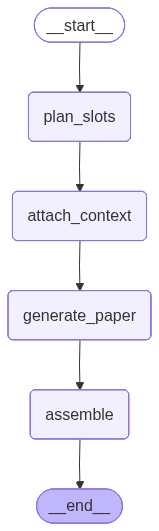

In [12]:
graph

In [13]:
result = graph.invoke(initial_state)

initial_batches:  [[{'slot_id': 'Q1', 'section_name': 'Section A', 'question_number': 1, 'question_type': 'MCQ', 'marks': 1.0, 'blooms_level': 'REMEMBERING', 'chapter_number': 1, 'chapter_name': 'Chapter 1', 'generation_mode': 'REUSE', 'has_internal_choice': False, 'sub_parts': [], 'context_chunks': [{'chunk_id': '2c2bc297-bab2-42e2-bd98-68ed2a92e0dd', 'text': 'REAL NUMBERS\n\n5\n\n**Solution :** The prime factorisation of 96 and 404 gives :\n\n$$96 = 2^5 \\times 3, 404 = 2^2 \\times 101$$\n\nTherefore, the HCF of these two integers is $2^2 = 4$.\n\n$$\\text{Also, } \\text{LCM } (96, 404) = \\frac{96 \\times 404}{\\text{HCF}(96, 404)} = \\frac{96 \\times 404}{4} = 9696$$\n\n**Example 4 :** Find the HCF and LCM of 6, 72 and 120, using the prime factorisation method.\n\n**Solution :** We have :\n\n$$6 = 2 \\times 3, 72 = 2^3 \\times 3^2, 120 = 2^3 \\times 3 \\times 5$$\n\nHere, $2^1$ and $3^1$ are the smallest powers of the common factors 2 and 3, respectively.\n\n$$\\text{So, } \\text{H

In [14]:
final_paper = result['final_paper']

In [15]:
final_answer_key = result['final_answer_key']

In [16]:
# _chapter_pool_cursor

In [17]:

from export_to_docx import export_question_paper_only, export_question_paper_and_answer_key



In [18]:
# export_question_paper_only(
#     question_paper=question_paper,
#     final_paper=final_paper,
#     reference_docx="sample.docx",
#     paper_out="question_paper.docx",
# )

In [19]:
export_question_paper_and_answer_key(
  question_paper=question_paper,
  final_paper=final_paper,
  final_answer_key=final_answer_key,
  reference_docx="sample.docx",
  paper_out="question_paper.docx",
  answer_key_out="generated_answer_key.docx"

)

('question_paper.docx', 'generated_answer_key.docx')